# Convolutional Neural Networks (CNNs) — a detailed study notebook

This notebook is a **descriptive, math-forward recap** of CNNs:

1. **Why CNNs were invented** (limitations of earlier models)
2. **Core ideas** (local connectivity, weight sharing, translation equivariance)
3. **Full math** (shapes, parameters, convolution definitions, gradients at a high level)
4. **Worked examples**:
   - a tiny **hand-computable convolution** (NumPy)
   - an **end-to-end CNN classifier** trained on the `sklearn` digits dataset (PyTorch)
5. **Diagrams** (made with Matplotlib)

> Tip: Run cells top-to-bottom. The training section is small and should run fast on CPU.


## 1) Why CNNs? What was wrong with “previous models”?

### The baseline before CNNs: fully-connected networks (MLPs)
If you represent an image as a vector and feed it to a dense network, you get:

- **Parameter explosion**  
  An image of size $H\times W$ (grayscale) has $HW$ inputs. A single dense layer with $M$ hidden units has $HW\cdot M$ weights.  
  Example: $128\times128$ image $\Rightarrow 16384$ inputs. With $M=1024$: **~16.7 million** weights just in the first layer.

- **No built-in notion of space**  
  Pixels that are neighbors in the image become far apart in the vector unless the network “learns” adjacency from scratch.

- **Poor inductive bias**  
  Images are *structured*: local patterns (edges, corners, textures) matter. Dense layers treat every pixel interaction as equally plausible.

- **Weak translation handling**  
  If an object shifts slightly, its pixels move to different indices. A dense net must re-learn features for many positions.

### The key insight
Images (and many signals) have **local statistics** and **repeated patterns** across space.

CNNs bake this into the architecture:
- **Local receptive fields**: focus on small neighborhoods.
- **Weight sharing**: use the *same* detector (kernel) everywhere.
- This yields **translation equivariance** (shift input → shifted feature map), and greatly reduced parameters.

### What problems did CNNs solve?
- Made image learning *data-efficient* by using the right inductive bias.
- Enabled deeper models by controlling parameter count and improving generalization.
- Provided feature hierarchies: edges → motifs → parts → objects.


## 2) Core building blocks of CNNs (conceptual)

### Convolution layer (usually cross-correlation)
A kernel (filter) slides over the input and produces a **feature map** indicating where a learned pattern appears.

**Key knobs**:
- **Kernel size**: e.g., $3\times 3$, $5\times 5$
- **Stride**: how far the window moves each step
- **Padding**: adding zeros (or other padding) around borders to control output size
- **Channels**:
  - Input: $C_{in}$ channels (e.g., RGB → 3)
  - Output: $C_{out}$ kernels → $C_{out}$ feature maps

### Nonlinearity
After convolution: ReLU is common

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

### Pooling (optional in modern CNNs)
Downsamples spatially to reduce resolution and add robustness.
- Max pool $2\times2$: keep the max in each window.

Many modern architectures use **strided convolutions** instead of pooling.

### Normalization (often BatchNorm)
Stabilizes training and helps deeper nets.

### A CNN as “learned feature extraction + classifier”
Convs build spatial features; later layers aggregate them to make decisions.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)


## 3) Diagram: sliding window intuition (2D)

Below we visualize a small input, a kernel, and the idea of sliding to build an output feature map.


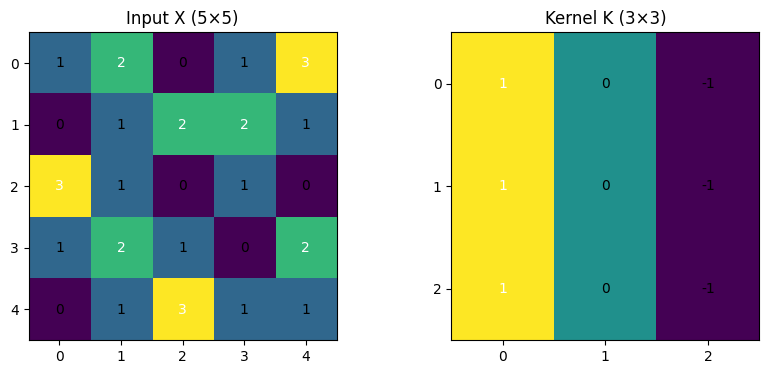

In [ ]:
def draw_grid(ax, data, title="", cmap="viridis", annotate=True):
    ax.imshow(data, cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    ax.set_xticklabels(range(data.shape[1]))
    ax.set_yticklabels(range(data.shape[0]))
    ax.grid(False)
    if annotate:
        vmax = float(np.max(data)) if np.max(data) != 0 else 1.0
        for (i, j), v in np.ndenumerate(data):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > vmax/2 else "black", fontsize=10)

# Tiny example
X = np.array([
    [1, 2, 0, 1, 3],
    [0, 1, 2, 2, 1],
    [3, 1, 0, 1, 0],
    [1, 2, 1, 0, 2],
    [0, 1, 3, 1, 1],
], dtype=float)

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)  # simple vertical edge detector

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_grid(axes[0], X, "Input X (5×5)")
draw_grid(axes[1], K, "Kernel K (3×3)")
plt.show()


## 4) The math (properly rendered with $ and $$)

### 4.1 Convolution vs cross-correlation
In deep learning frameworks, the operation called “convolution” is usually **cross-correlation**:

For input $X$ and kernel $K$, output $Y$ is:

$$
Y[i,j] = \sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1} X[i+u,\, j+v]\,K[u,v]
$$

This is cross-correlation (no kernel flip).  
True convolution flips the kernel. In learning, it doesn’t matter because $K$ is learned.

### 4.2 Output size formula (2D)
Let input be $H\times W$, kernel $k_h\times k_w$, padding $p_h,p_w$, stride $s_h,s_w$.
Then output spatial size is:

$$
H_{out}=\left\lfloor\frac{H+2p_h-k_h}{s_h}\right\rfloor+1,\qquad
W_{out}=\left\lfloor\frac{W+2p_w-k_w}{s_w}\right\rfloor+1
$$

### 4.3 Multi-channel convolution
Input $X\in\mathbb{R}^{C_{in}\times H\times W}$.  
A single output channel uses a kernel tensor $W\in\mathbb{R}^{C_{in}\times k_h\times k_w}$ plus bias $b\in\mathbb{R}$.

For output channel $c$:

$$
Y_c[i,j] = b_c + \sum_{c'=1}^{C_{in}}\sum_{u,v} X_{c'}[i+u,\,j+v]\,W_{c,c'}[u,v]
$$

With $C_{out}$ output channels:

$$
W \in \mathbb{R}^{C_{out}\times C_{in}\times k_h\times k_w},\qquad b\in\mathbb{R}^{C_{out}}
$$

### 4.4 Parameter count
A dense layer from $HWC_{in}$ inputs to $M$ outputs has:

$$
(HWC_{in})\cdot M + M \text{ parameters}
$$

A conv layer has:

$$
(C_{out}\cdot C_{in}\cdot k_h\cdot k_w) + C_{out}
$$

Notice: **independent of $H,W$** — huge win.

### 4.5 Translation equivariance
If $T_{\Delta}$ shifts the input by $\Delta$, then (ignoring borders):

$$
\mathrm{Conv}(T_{\Delta}X) = T_{\Delta}(\mathrm{Conv}(X))
$$

This is why CNN features “move with the object.” Pooling/strides then introduce some *approximate invariance*.

### 4.6 Backprop intuition (high-level but real)
For a conv layer $Y = X \star W$ (cross-correlation), gradients satisfy:

- Gradient w.r.t. weights accumulates correlations between input patches and upstream gradients:

$$
\frac{\partial \mathcal{L}}{\partial W} \;\sim\; X \star \frac{\partial \mathcal{L}}{\partial Y}
$$

- Gradient w.r.t. input is convolution/correlation of upstream gradient with transformed weights (details depend on definition):

$$
\frac{\partial \mathcal{L}}{\partial X} \;\sim\; \frac{\partial \mathcal{L}}{\partial Y} * \widetilde{W}
$$

Deep learning libraries implement this efficiently.


## 5) Worked example 1: implement a 2D convolution (cross-correlation) in NumPy

We’ll compute the output feature map from the earlier $5\times 5$ input and $3\times 3$ kernel.


In [ ]:
def conv2d_valid(X, K, stride=1):
    # 2D cross-correlation with VALID padding (no padding).
    # X: (H, W), K: (kH, kW)
    H, W = X.shape
    kH, kW = K.shape
    outH = (H - kH) // stride + 1
    outW = (W - kW) // stride + 1
    Y = np.zeros((outH, outW), dtype=float)
    for i in range(outH):
        for j in range(outW):
            patch = X[i*stride:i*stride+kH, j*stride:j*stride+kW]
            Y[i, j] = np.sum(patch * K)
    return Y

Y = conv2d_valid(X, K, stride=1)
Y


array([[ 2.,  0., -2.],
       [ 1.,  1.,  0.],
       [ 0.,  2.,  1.]])

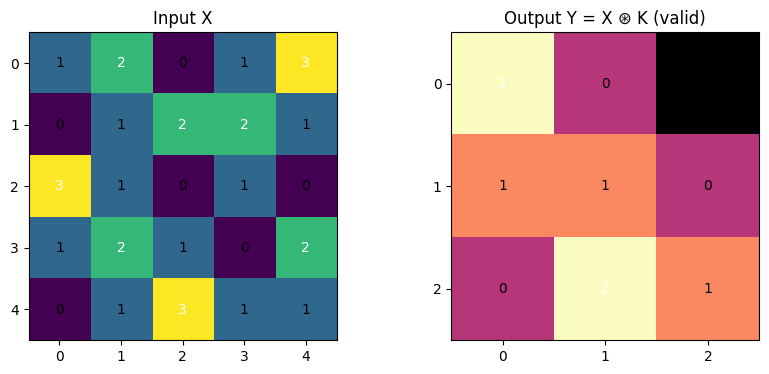

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_grid(axes[0], X, "Input X", cmap="viridis")
draw_grid(axes[1], Y, "Output Y = X ⊛ K (valid)", cmap="magma")
plt.show()


### A tiny “single-location” calculation (hand-check)

Take the top-left $3\times3$ patch of $X$ and multiply elementwise with $K$, then sum:

$$
Y[0,0] = \sum_{u,v} X[u,v]K[u,v]
$$

We’ll print that patch and compute it explicitly.


In [ ]:
patch00 = X[0:3, 0:3]
patch00, float(np.sum(patch00 * K))


(array([[1., 2., 0.],
        [0., 1., 2.],
        [3., 1., 0.]]),
 2.0)

## 6) Padding and stride: output size & border effects

Let’s visualize how **padding** changes output shape and preserves edge information.


Original: (5, 5) -> valid out: (3, 3)
Padded  : (7, 7) -> valid out: (5, 5)


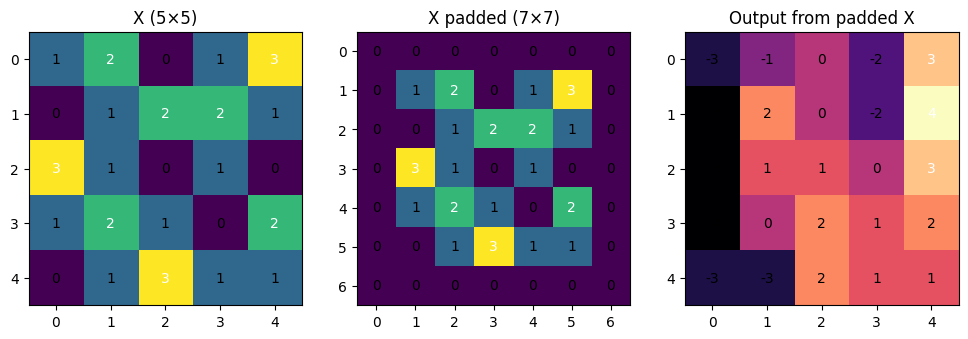

In [ ]:
def pad2d(X, pad=1, value=0.0):
    return np.pad(X, ((pad, pad), (pad, pad)), mode="constant", constant_values=value)

Xp = pad2d(X, pad=1)
Yp = conv2d_valid(Xp, K, stride=1)

print("Original:", X.shape, "-> valid out:", Y.shape)
print("Padded  :", Xp.shape, "-> valid out:", Yp.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_grid(axes[0], X, "X (5×5)", cmap="viridis")
draw_grid(axes[1], Xp, "X padded (7×7)", cmap="viridis")
draw_grid(axes[2], Yp, "Output from padded X", cmap="magma")
plt.show()


## 7) From math to models: a minimal CNN for classification

We’ll train a small CNN on the **digits** dataset (8×8 grayscale, classes 0–9).  
This dataset ships with scikit-learn, so it doesn’t require any downloads.

### Architecture (tiny but real)
- Conv(1→16, 3×3, padding=1) + ReLU
- MaxPool(2×2)
- Conv(16→32, 3×3, padding=1) + ReLU
- MaxPool(2×2)
- Flatten
- Linear → 10 classes


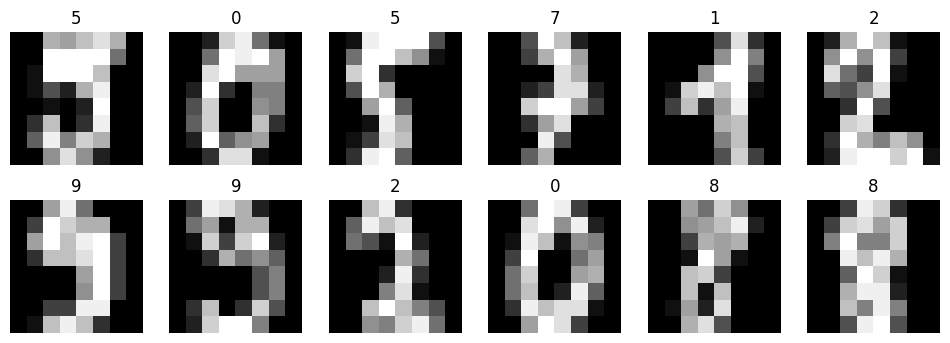

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

digits = load_digits()
X_all = digits.images.astype(np.float32)  # (N, 8, 8)
y_all = digits.target.astype(np.int64)

# Normalize to roughly [0,1]
X_all = X_all / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

class DigitsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)  # (N, 1, 8, 8)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = DigitsDataset(X_train, y_train)
test_ds  = DigitsDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

# Quick look at a few samples
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, (img, label) in zip(axes.flatten(), [train_ds[i] for i in range(12)]):
    ax.imshow(img.squeeze(0), cmap="gray", interpolation="nearest")
    ax.set_title(int(label))
    ax.axis("off")
plt.show()


In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # keep 8x8
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # keep 4x4 after pool
        self.fc = nn.Linear(32 * 2 * 2, 10)  # after two 2x2 pools: 8->4->2

    def forward(self, x):
        x = F.relu(self.conv1(x))      # (N,16,8,8)
        x = F.max_pool2d(x, 2)         # (N,16,4,4)
        x = F.relu(self.conv2(x))      # (N,32,4,4)
        x = F.max_pool2d(x, 2)         # (N,32,2,2)
        x = torch.flatten(x, 1)        # (N,128)
        x = self.fc(x)                 # (N,10)
        return x

model = SmallCNN()
model


SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_acc = 0.0
    total_n = 0
    total_loss = 0.0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            acc = accuracy_from_logits(logits, yb)
            n = Xb.size(0)
            total_loss += loss.item() * n
            total_acc += acc * n
            total_n += n
    return total_loss / total_n, total_acc / total_n

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

epochs = 12
for epoch in range(1, epochs + 1):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_acc = evaluate(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | test loss {te_loss:.4f} acc {te_acc:.4f}")


Epoch 01 | train loss 2.2136 acc 0.6180 | test loss 2.2143 acc 0.6333
Epoch 02 | train loss 2.0362 acc 0.8072 | test loss 2.0417 acc 0.8000
Epoch 03 | train loss 1.6753 acc 0.8455 | test loss 1.6909 acc 0.8306
Epoch 04 | train loss 1.1586 acc 0.8692 | test loss 1.1878 acc 0.8361
Epoch 05 | train loss 0.7256 acc 0.8991 | test loss 0.7610 acc 0.8722
Epoch 06 | train loss 0.4852 acc 0.9081 | test loss 0.5282 acc 0.8722
Epoch 07 | train loss 0.3672 acc 0.9221 | test loss 0.4049 acc 0.8917
Epoch 08 | train loss 0.3032 acc 0.9283 | test loss 0.3318 acc 0.9194
Epoch 09 | train loss 0.2391 acc 0.9527 | test loss 0.2666 acc 0.9222
Epoch 10 | train loss 0.2110 acc 0.9548 | test loss 0.2423 acc 0.9306
Epoch 11 | train loss 0.1798 acc 0.9659 | test loss 0.2114 acc 0.9417
Epoch 12 | train loss 0.1579 acc 0.9666 | test loss 0.1833 acc 0.9556


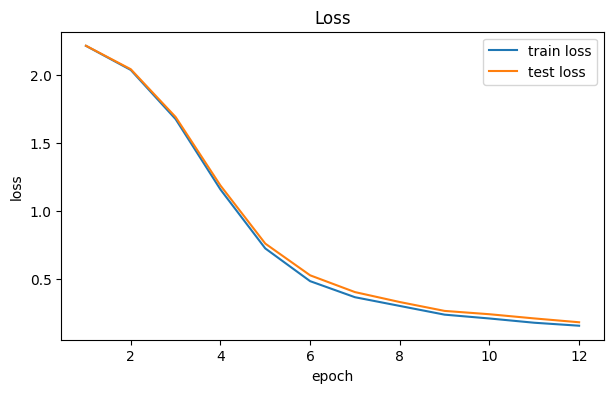

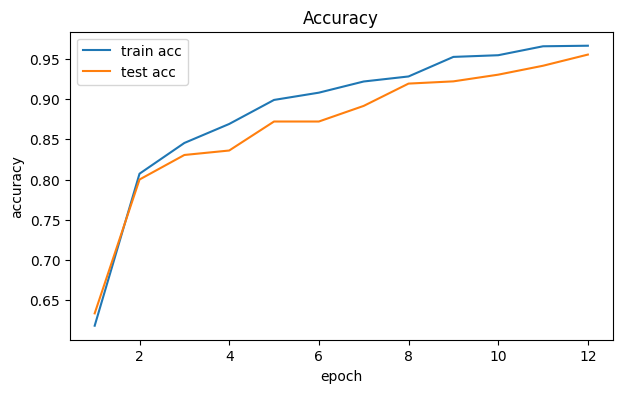

In [ ]:
epochs_range = np.arange(1, epochs + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_loss"], label="train loss")
plt.plot(epochs_range, history["test_loss"], label="test loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_acc"], label="train acc")
plt.plot(epochs_range, history["test_acc"], label="test acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy")
plt.show()


## 8) Diagram: learned kernels and feature maps

We’ll visualize:
- some learned kernels from the first conv layer (16 filters of size 3×3)
- feature maps produced for one sample image


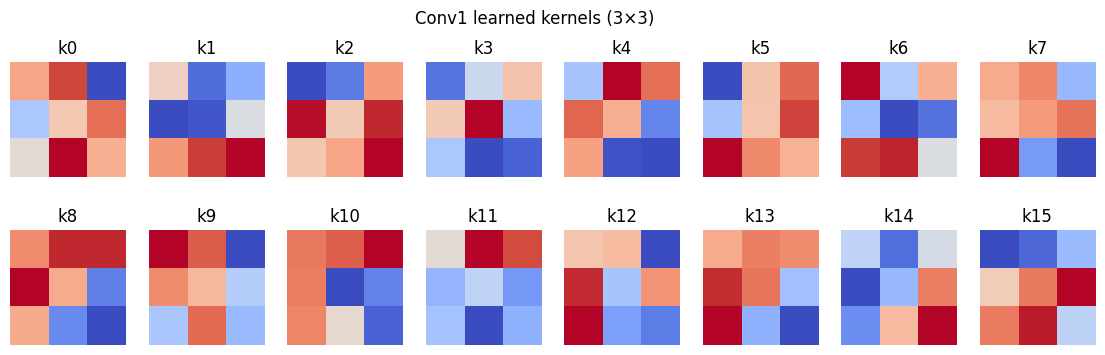

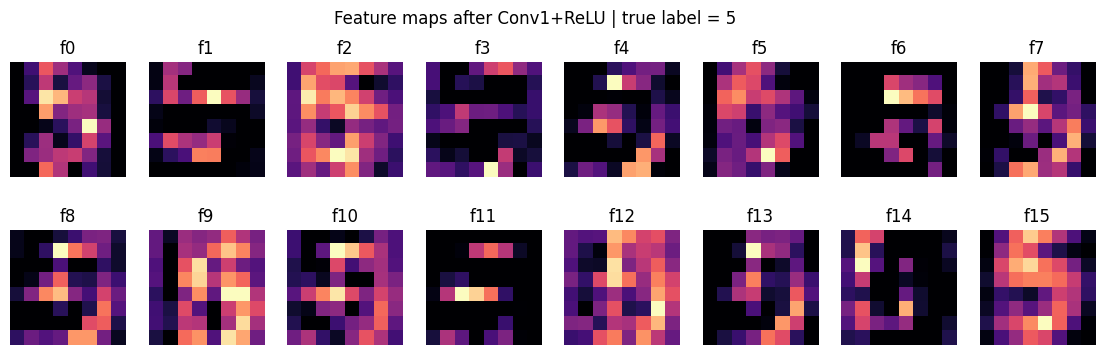

In [ ]:
# Pick one test sample
X_sample, y_sample = test_ds[0]
X_sample_batch = X_sample.unsqueeze(0).to(device)

# Extract conv1 weights
W1 = model.conv1.weight.detach().cpu().numpy()  # (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(W1[i, 0], cmap="coolwarm", interpolation="nearest")
    ax.set_title(f"k{i}")
    ax.axis("off")
plt.suptitle("Conv1 learned kernels (3×3)")
plt.show()

model.eval()
with torch.no_grad():
    fmap = F.relu(model.conv1(X_sample_batch)).detach().cpu().numpy()[0]  # (16, 8, 8)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fmap[i], cmap="magma", interpolation="nearest")
    ax.set_title(f"f{i}")
    ax.axis("off")
plt.suptitle(f"Feature maps after Conv1+ReLU | true label = {int(y_sample)}")
plt.show()


## 9) Recap: what to remember

### CNN “superpowers” (inductive biases)
- **Locality**: nearby pixels interact first.
- **Weight sharing**: same filter applied everywhere → fewer params.
- **Translation equivariance**: shifting the input shifts feature maps.
- **Hierarchy**: early layers learn edges/textures; deeper layers learn parts/objects.
- **Computation scales well**: convolution is highly optimized on CPUs/GPUs.

### Design knobs you’ll keep using
- kernel size, stride, padding, channels
- depth vs resolution (pooling/stride trade-offs)
- regularization (weight decay, dropout), data augmentation
- normalization (BatchNorm) and residual connections (ResNet)

### Next steps
- Receptive field growth, dilation
- ResNet / MobileNet / ConvNeXt
- Interpretability: saliency, feature visualization, probing intermediate activations
